# **Representation Learning in EHR Data Using MIMIC-IV**  

### **Introduction**  

Electronic Health Records (EHR) contain vast amounts of structured and unstructured medical data, including **diagnoses, procedures, medications, and lab results**. One way to extract meaningful insights from this data is through **representation learning**, where we learn vector embeddings of medical concepts (e.g., ICD-10 codes) based on their co-occurrence in patient visits.  

In this notebook, we will apply **Word2Vec** to **ICD-10 diagnosis codes** extracted from the **MIMIC-IV Demo dataset**. By doing so, we aim to learn representations that capture **semantic and clinical relationships** between diseases, allowing us to identify conditions that frequently co-occur in real-world hospital visits. We will evaluate local semantics in different ways.
 

### **Tasks**  

1. **Data Extraction:** Load the **ICD-10 diagnosis codes** from **MIMIC-IV `diagnoses_icd.csv`**.  
2. **Preprocessing:** Structure the data into **patient visit sequences**, grouping ICD codes by hospital admission (`hadm_id`).  
3. **Training Word2Vec Model:** Use a **Skip-gram model** to learn vector representations of ICD-10 codes.  
4. **Evaluating Similarities:** Retrieve the most similar diagnosis codes for a given ICD-10 condition and analyze their **clinical relationships**.  
5. **Clinical Interpretation:** Explain why the retrieved diagnoses are related and how this approach could support **clinical decision-making**.
6. **Medical Analogies (Vector Arithmetic):** Perform "analogies of type: “Condition A is to Symptom A as Condition B is to [?]”.
7. **Comparative Similarity Analysis:** Compare the similarity of "Related" vs. "Unrelated" pairs.




### Import Python libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
##!pip install gensim
from gensim.models import Word2Vec

### Step 1: Load Data from MIMIC-IV 

In [2]:
path = "data/mimic-iv-clinical-database-demo-2.2/" #path to the data folder 
df_diagnoses = pd.read_csv(path+'hosp/diagnoses_icd.csv.gz')
print(df_diagnoses.head())

   subject_id   hadm_id  seq_num icd_code  icd_version
0    10035185  22580999        3     4139            9
1    10035185  22580999       10     V707            9
2    10035185  22580999        1    41401            9
3    10035185  22580999        9     3899            9
4    10035185  22580999       11    V8532            9


### Step 2: Preprocess Data

The **`diagnoses_icd.csv`** file contains the following key columns:  
- **`subject_id`**: Unique identifier for each patient.  
- **`hadm_id`**: Unique identifier for each hospital admission (visit).  
- **`icd_code`**: The ICD-10 diagnosis code.  
- **`icd_version`**: Indicates whether the code is ICD-9 (9) or ICD-10 (10).  

We need to **filter ICD-10 codes** and **group them by hospital admission** to prepare the dataset for training the Word2Vec model.  


In [3]:
# Filter for ICD-10 codes
df_diagnoses = df_diagnoses[df_diagnoses["icd_version"] == 10]

# Group ICD codes by hospital admission (visit)
ehr_data = df_diagnoses.groupby("hadm_id")["icd_code"].apply(list).tolist()

# Display the number of patient visits
print("Number of patient visits: ", len(ehr_data))

# Display the first few patient visits
print("The first visits: ")
print(ehr_data[:3])


Number of patient visits:  123
The first visits: 
[['R600', 'K921', 'F10239', 'Z9884', 'S0003XA', 'N186', 'W108XXA', 'M109', 'K7030', 'S20221A', 'S40022A', 'S20222A', 'I8510', 'Z8711', 'S40021A', 'S8012XA', 'D696', 'R740', 'K7040', 'S8011XA', 'D638', 'F17210', 'R748', 'Z86718', 'F10251', 'Z992', 'E039', 'I120', 'D62', 'J45909', 'Y92018', 'E872'], ['I9751', 'I871', 'Y838', 'Y92234', 'I82422'], ['M542', 'D696', 'R45851', 'R51', 'F39', 'F17210', 'B1920', 'Z9114', 'W19XXXA', 'Y929', 'B20', 'S0990XA']]


Each patient hospital visit is consider a sequence of diagnoses (of different size).

In [4]:
# Display 10 unique ICD-10 codes in the dataset
print(df_diagnoses["icd_code"].unique()[:10])

['D696' 'S030XXA' 'S25512A' 'D649' 'F1010' 'S0262XA' 'Y040XXA' 'S36892A'
 'I4891' 'I959']


Let's compute some statistics:

Patient visit size range: 3 - 39
mean size of patient visit:  18.804878048780488


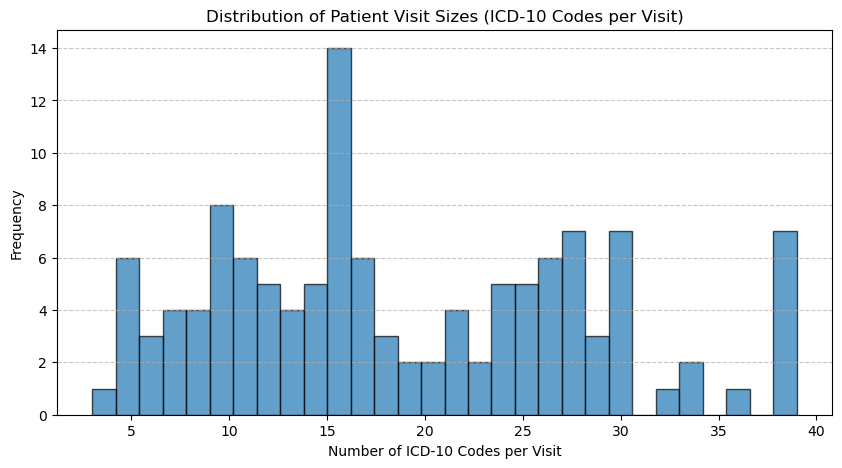

In [5]:
import statistics

# Calculate the size of each patient visit (number of ICD codes per visit)
visit_sizes = [len(codes) for codes in ehr_data]

# Get the range (minimum and maximum number of codes per visit)
min_size = min(visit_sizes)
max_size = max(visit_sizes)

# Print the interval of visit sizes
print(f"Patient visit size range: {min_size} - {max_size}")

# Print the mean size of patient visit
print(f"mean size of patient visit: ", statistics.mean(visit_sizes))

# Plot the histogram
plt.figure(figsize=(10, 5))
plt.hist(visit_sizes, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel("Number of ICD-10 Codes per Visit")
plt.ylabel("Frequency")
plt.title("Distribution of Patient Visit Sizes (ICD-10 Codes per Visit)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()




#### **Step 3: Train Word2Vec Model**  

Now, let's train a **Word2Vec Skip-gram model** on the patient visit sequences:  



In [6]:
# Train Word2Vec model
model = Word2Vec(sentences=ehr_data, vector_size=100, window=7, min_count=1, sg=1, workers=4)

# Save the model for future use
model.save("mimic_word2vec.model")

In [7]:
print("Vocabulary size:", len(list(model.wv.index_to_key)))

Vocabulary size: 734



#### **Step 4: Retrieve Similar Medical ICD-10 Codes**  

Now, let's test the trained model by finding the **most similar ICD-10 codes** to a given diagnosis.

We pick an anchor code (E785 for Hyperlipidemia) and retrieve its top 5 most similar codes. 



In [8]:

# Pick the ICD code
example_code = 'E785'  

# You can change index to any valid code:
# Get the vocabulary (all words in the model)
vocab_list = list(model.wv.index_to_key)  # List of all trained ICD-10 codes
# Pick a random ICD code from the trained vocabulary:
# example_code = vocab_list[0]  

# Find the top 5 similar codes
similar_codes = model.wv.most_similar(example_code, topn=5)

# Print results
print(f"Most similar codes to {example_code}:")
for code, similarity in similar_codes:
    print(f"Code: {code}, Similarity: {similarity:.4f}")

Most similar codes to E785:
Code: E119, Similarity: 0.9826
Code: I2510, Similarity: 0.9816
Code: N179, Similarity: 0.9805
Code: E039, Similarity: 0.9794
Code: I129, Similarity: 0.9794


#### **Step 5: Clinical Interpretation of the Results:**

The most similar codes, based on Word2Vec embeddings, to **E785 (Hyperlipidemia)** are:
1. **E119**: Type 2 diabetes
2. **I2510**: Atherosclerotic heart disease of native coronary artery
3. **N179**: Chronic kidney disease, unspecified
4. **E039**: Hypothyroidism, unspecified
5. **I129**: Hypertensive heart disease with heart failure

We can **clinically interpret** the results obtained for the ICD-10 code **E78.5 (Hyperlipidemia, unspecified)** and analyze its most similar codes based on Word2Vec embeddings.  

#### **ICD-10 Code: E78.5 (Hyperlipidemia, unspecified)**  
Hyperlipidemia refers to **elevated levels of lipids (fats) in the blood**, including **cholesterol and triglycerides**. It is a major risk factor for **cardiovascular disease (CVD)**, including **coronary artery disease (CAD), stroke, and hypertension**.  

Your Word2Vec model suggests that the following ICD-10 codes are most **similar** based on co-occurrence in patient visits. Let's analyze them one by one.  

#### **Most similar codes to E785 (Hyperlipidemia)**:

1. **E119 (Type 2 Diabetes)**  
   - **Interpretation**: **Type 2 Diabetes (E11.9)** is highly associated with **hyperlipidemia (E78.5)**, as both are components of **metabolic syndrome**.  
   - **Clinical Relevance**: Many **diabetic** patients also have **dyslipidemia**, requiring lipid-lowering therapy (e.g., statins) to reduce cardiovascular risk.  
   - **Expected?** ✅ Yes, strong clinical relationship.  
     
2. **I2510 (Atherosclerotic Heart Disease of Native Coronary Artery)**  
   - **Interpretation**: **Atherosclerotic heart disease (I25.10)** is a **common complication of hyperlipidemia (E78.5)**, as elevated lipid levels contribute to plaque formation in the coronary arteries, leading to coronary artery disease.  
   - **Clinical Relevance**: Patients with **hyperlipidemia** are at a higher risk of developing **atherosclerotic heart disease** and may require interventions such as **statins** and **coronary artery bypass grafting (CABG)**.  
   - **Expected?** ✅ Yes, clinically expected relationship.  

3. **N179 (Chronic Kidney Disease, Unspecified)**  
   - **Interpretation**: **Chronic kidney disease (N17.9)** can result from **hyperlipidemia (E78.5)**, particularly in patients with **diabetes** or **hypertension**, as both conditions are known to accelerate kidney damage.  
   - **Clinical Relevance**: Both **hyperlipidemia** and **chronic kidney disease (CKD)** are part of the broader **cardiovascular** and **metabolic syndrome** continuum, necessitating management of **lipid levels** to slow kidney decline.  
   - **Expected?** ✅ Yes, clinically expected relationship.  

4. **E039 (Hypothyroidism, Unspecified)**  
   - **Interpretation**: **Hypothyroidism (E03.9)** is often accompanied by **dyslipidemia**, with elevated **LDL cholesterol** and **total cholesterol** being common findings in hypothyroid patients.  
   - **Clinical Relevance**: Treatment of **hypothyroidism** can improve **lipid profiles**, and **lipid-lowering agents** may be necessary if **hyperlipidemia** persists.  
   - **Expected?** ✅ Yes, strong clinical relationship, as hypothyroidism frequently causes lipid abnormalities.  

5. **I129 (Hypertensive Heart Disease with Heart Failure)**  
   - **Interpretation**: **Hypertensive heart disease (I13.9)** is closely linked to **hyperlipidemia (E78.5)**, as both conditions are prevalent in individuals with **chronic hypertension**. Elevated lipids exacerbate **heart failure** by worsening atherosclerosis.  
   - **Clinical Relevance**: **Hyperlipidemia** management is essential in patients with **hypertensive heart disease**, as lowering lipid levels can reduce the risk of **heart failure** progression and associated **cardiovascular events**.  
   - **Expected?** ✅ Yes, clinically expected relationship.



#### **Summary:**
The selected **most similar codes** to **E785 (Hyperlipidemia)** reflect **interconnected chronic diseases**, especially those related to **cardiovascular** and **metabolic** health. These conditions share common risk factors, such as **hypertension**, **diabetes**, and **obesity**, and often co-occur due to overlapping pathophysiological mechanisms, such as **dyslipidemia** and **atherosclerosis**. The relationships are **clinically meaningful** and **expected** based on common treatment goals, including **lipid-lowering therapies** like **statins** to reduce **cardiovascular risk**.


#### **Step 6: Medical Analogies (Vector Arithmetic)**

In representation learning, if a model is well-trained, you should be able to perform "analogies." 

For example: “Condition A is to Symptom A as Condition B is to [?]”.


In [9]:
# Load the dictionary of ICD-10 code names
df_dic = pd.read_csv(path + 'hosp/d_icd_diagnoses.csv.gz')

# Create a mapping dictionary for quick lookup
# Note: strip() is used to ensure no accidental spaces interfere with matching
code_to_name = dict(zip(df_dic['icd_code'].str.strip(), df_dic['long_title']))

In [10]:
def medical_analogy(model, a, b, c):
    """
    Solves and prints the analogy: a is to b as c is to ?
    Includes the clinical names of the codes.
    """
    def get_name(code):
        return code_to_name.get(code, "Unknown Code")

    try:
        # Perform vector arithmetic: b - a + c
        result = model.wv.most_similar(positive=[b, c], negative=[a], topn=3)
        
        print(f"Analogy: {get_name(a)} ({a})")
        print(f"       is to {get_name(b)} ({b})")
        print(f"       as {get_name(c)} ({c})")
        print(f"       is to:")
        
        for i, (code, score) in enumerate(result):
            print(f"  {i+1}. {get_name(code)} ({code}) - Similarity: {score:.4f}")
            
    except KeyError as e:
        print(f"One of the codes was not found in the training data: {e}")

# Example Usage
print("--- Medical Analogies ---")
# Example: Hypertension is to Heart Failure as Diabetes is to...
medical_analogy(model, 'I10', 'I509', 'E119')

--- Medical Analogies ---
Analogy: Essential (primary) hypertension (I10)
       is to Heart failure, unspecified (I509)
       as Type 2 diabetes mellitus without complications (E119)
       is to:
  1. Unspecified place in hospital as the place of occurrence of the external cause (Y92239) - Similarity: 0.9074
  2. Patient room in hospital as the place of occurrence of the external cause (Y92230) - Similarity: 0.9055
  3. Obesity, unspecified (E669) - Similarity: 0.9026


**Observation:**

The result is confusing. It gives high similarity to unrelated concets: Type 2 diabetes mellitus without complications (E119) and Patient room in hospital as the place of occurrence of the external cause (Y92230) - Similarity: 0.9055

This confusion is a classic symptom of the "Small Data Problem" in representation learning. When you train a Word2Vec model on only 100-120 visits, the model does not have enough "examples" to distinguish between a clinical relationship and a coincidental co-occurrence.

Why is this happening? Two possible reasons:

- Spurious Correlations: In a small dataset, if a specific patient happened to have Type 2 Diabetes (E119) and their record also included the location code for "Patient room in hospital" (Y92230), the model sees these two together. Because the total number of sentences (patient visits) is so small, appearing together just few times creates a very strong mathematical bond.

- Lack of Negative Samples: Word2Vec learns by seeing which codes appear together versus which ones don't. In a small dataset, almost every code is "rare," so the model struggles to learn what doesn't belong together.

- The "Single Visit" Effect: If Y92230 only appears in one patient's record, and that patient has E119, the model essentially thinks they are synonyms because their contexts are identical in its limited world.

How to fix and interpret this:

To try to make the analysis meaningful with the Demo subset, we should modify the approach to account for code frequency. 

We want to ignore "noise" codes that appear too rarely to have learned a real meaning.

1. Filter by Frequency (Adjusting Word2Vec)

    When you initialize your Word2Vec model, set a min_count. This tells the model: "Ignore any code that appears fewer than X times." 

In [11]:
# Re-train with a min_count filter to remove rare/noise codes
model = Word2Vec(
    sentences=ehr_data, 
    vector_size=100, 
    window=5, 
    min_count=3,  # Ignore codes that appear less than 3 times
    workers=4
)

2. Retrain the model:

In [12]:
# Train Word2Vec model
model = Word2Vec(sentences=ehr_data, vector_size=100, window=7, min_count=1, sg=1, workers=4)

# Save the model for future use
model.save("mimic_word2vec.model")

3. Enhanced Analogy Function (with Frequency Check)

    Let's update the function to show you how many times the codes appeared. This will help you identify if a "similar" code is just a rare code that happened to appear once with your target.

    First, create a frequency map from your training data:

In [13]:
from collections import Counter

# Flatten all visits into one list of codes to count them
all_codes = [code for visit in ehr_data for code in visit]
code_counts = Counter(all_codes)

Now, use this updated function:

In [14]:
def medical_analogy_refined(model, a, b, c):
    def get_info(code):
        name = code_to_name.get(code, "Unknown")
        count = code_counts.get(code, 0)
        return f"{name} (Code: {code}, Count: {count})"

    try:
        result = model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
        
        print(f"Analogy: {get_info(a)}")
        print(f"       is to {get_info(b)}")
        print(f"       as {get_info(c)}")
        print(f"       is to:")
        
        for i, (code, score) in enumerate(result):
            print(f"  {i+1}. {get_info(code)}")
            print(f"     -> Similarity Score: {score:.4f}")
            
    except KeyError as e:
        print(f"Error: {e}. This code might have been filtered out by min_count.")

# Run the test again
medical_analogy_refined(model, 'I10', 'I509', 'E119')

Analogy: Essential (primary) hypertension (Code: I10, Count: 32)
       is to Heart failure, unspecified (Code: I509, Count: 5)
       as Type 2 diabetes mellitus without complications (Code: E119, Count: 26)
       is to:
  1. Unspecified place in hospital as the place of occurrence of the external cause (Code: Y92239, Count: 7)
     -> Similarity Score: 0.9074
  2. Patient room in hospital as the place of occurrence of the external cause (Code: Y92230, Count: 12)
     -> Similarity Score: 0.9055
  3. Obesity, unspecified (Code: E669, Count: 22)
     -> Similarity Score: 0.9026
  4. Long term (current) use of insulin (Code: Z794, Count: 37)
     -> Similarity Score: 0.9012
  5. Long term (current) use of anticoagulants (Code: Z7901, Count: 21)
     -> Similarity Score: 0.9001


#### **Exercise 1: Discuss what you observe and extract conclusions of the result.**  

#### **Step 7: Comparative Similarity Analysis**

We can quantitatively prove the model is working by comparing the similarity of "Related" vs. "Unrelated" pairs.

In [15]:


import numpy as np
from collections import Counter

# 1. First, calculate the counts from your training sequences (ehr_data)
# This creates a dictionary where the key is the code and value is the frequency
all_codes_list = [code for visit in ehr_data for code in visit]
code_counts = Counter(all_codes_list)

def evaluate_similarities_with_counts(model, related_pairs, unrelated_pairs):
    print("--- Comparative Similarity Analysis (with Frequencies) ---")
    
    def process_group(name, pairs):
        print(f"\nEvaluating Group: {name}")
        print("-" * 80)
        sims = []
        for c1, c2 in pairs:
            if c1 in model.wv and c2 in model.wv:
                # Calculate similarity
                score = model.wv.similarity(c1, c2)
                sims.append(score)
                
                # Get names and counts
                n1 = code_to_name.get(c1, "Unknown")
                count1 = code_counts.get(c1, 0)
                
                n2 = code_to_name.get(c2, "Unknown")
                count2 = code_counts.get(c2, 0)

                # Printed Output with Counts
                print(f"Pair: {n1} ({c1}) [Count: {count1}]")
                print(f"      + {n2} ({c2}) [Count: {count2}]")
                print(f"      -> Similarity: {score:.4f}\n")
            else:
                missing = [c for c in [c1, c2] if c not in model.wv]
                print(f"Skipping pair ({c1}, {c2}): {missing} not in vocabulary.\n")
        
        avg = np.mean(sims) if sims else 0
        print(f"Average Similarity for {name}: {avg:.4f}")
        return avg

    rel_avg = process_group("Related Pairs", related_pairs)
    unrel_avg = process_group("Unrelated Pairs", unrelated_pairs)
    
    if unrel_avg > 0:
        print("\n" + "="*80)
        print(f"FINAL RATIO (Related/Unrelated): {rel_avg/unrel_avg:.2f}x")
        print("="*80)



# Define the pairs
# Related Pairs: These codes often appear in the same 'visit' in MIMIC
related = [
    ('I10', 'I509'),   # Hypertension + Heart Failure
    ('E119', 'E785'),  # Type 2 Diabetes + Hyperlipidemia
    ('N186', 'Z992'),  # ESRD + Dialysis Dependence
    ('I4891', 'I10'),  # Atrial Fibrillation + Hypertension
    ('E119', 'N186'),  # Diabetes + Kidney Disease
    ('I509', 'I4891'), # Heart Failure + Atrial Fibrillation
    ('J449', 'I10'),   # COPD + Hypertension
    ('E785', 'I10')    # Hyperlipidemia + Hypertension
]

# Unrelated Pairs: Conditions that are clinically distinct
# Note: In a small dataset, these might still show high similarity due to co-occurrence
unrelated = [
    ('A419', 'E119'),  # Sepsis + Diabetes
    ('J189', 'I10'),   # Pneumonia + Hypertension
    ('N390', 'E785'),  # Urinary Tract Infection + Hyperlipidemia
    ('D649', 'I4891'), # Anemia + Atrial Fibrillation
    ('F329', 'N186'),  # Major Depressive Disorder + ESRD
    ('G309', 'I509'),  # Alzheimer's + Heart Failure
    ('K219', 'A419'),  # GERD (Reflux) + Sepsis
    ('Z853', 'I10')    # History of Breast Cancer + Hypertension
]


# Run the evaluation
evaluate_similarities_with_counts(model, related, unrelated)

--- Comparative Similarity Analysis (with Frequencies) ---

Evaluating Group: Related Pairs
--------------------------------------------------------------------------------
Pair: Essential (primary) hypertension (I10) [Count: 32]
      + Heart failure, unspecified (I509) [Count: 5]
      -> Similarity: 0.9119

Pair: Type 2 diabetes mellitus without complications (E119) [Count: 26]
      + Hyperlipidemia, unspecified (E785) [Count: 57]
      -> Similarity: 0.9826

Pair: End stage renal disease (N186) [Count: 12]
      + Dependence on renal dialysis (Z992) [Count: 11]
      -> Similarity: 0.9014

Pair: Unspecified atrial fibrillation (I4891) [Count: 23]
      + Essential (primary) hypertension (I10) [Count: 32]
      -> Similarity: 0.9734

Pair: Type 2 diabetes mellitus without complications (E119) [Count: 26]
      + End stage renal disease (N186) [Count: 12]
      -> Similarity: 0.9382

Pair: Heart failure, unspecified (I509) [Count: 5]
      + Unspecified atrial fibrillation (I4891) [

#### **Exercise 2: Discuss what you observe and extract conclusions of the result.**  